pysorb Fit Example

Model: Dual-Site Langmuir
Metrics: {'R2': 0.9994760397375905, 'RMSE': 0.02076388023752449, 'MAE': 0.01741678142880844, 'ARE': 0.01989800571758304}
Parameters:
qs1: 3.14211
log10(b01): -4.29985
dH1: -23336.7
qs2: 0.936645
log10(b02): -3.33709
dH2: -23410.9


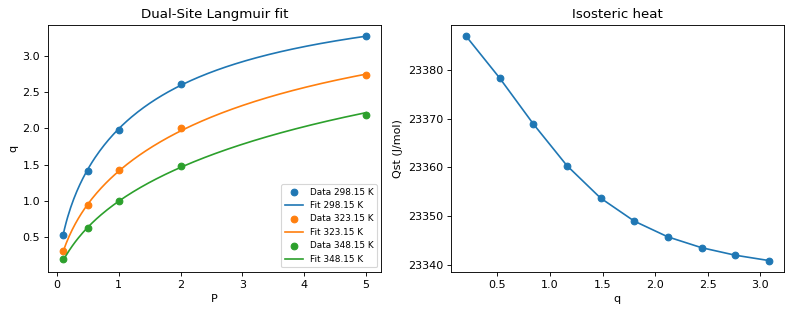

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pysorb.fit import fit_isotherm, MULTI_T_MODELS, isosteric_heat_for_loadings

P = np.tile([0.1, 0.5, 1, 2, 5], 3)
q = np.array([0.52,1.41,1.98,2.61,3.28,
              0.31,0.94,1.43,2.01,2.74,
              0.19,0.62,0.99,1.48,2.18])
T = np.repeat([298.15, 323.15, 348.15], 5)

res = fit_isotherm(
    P, q, T, "Dual-Site Langmuir",
    mode="multi", metric="RMSE",
    constraints="qs1 + qs2 < 5; qs1 > 0",
    random_state=1
)

p = res.parameters_by_name
print("Model:", res.model_label)
print("Metrics:", res.metrics)
print("Parameters:")
for k, v in p.items():
    print(f"{k}: {v:.6g}")

model = MULTI_T_MODELS[res.model_name].function
P_grid = np.linspace(P.min(), P.max(), 200)
temps = np.unique(T)

plt.figure(figsize=(10, 4), dpi = 80)

plt.subplot(1, 2, 1)
for Ti in temps:
    m = T == Ti
    plt.scatter(P[m], q[m], label=f"Data {Ti:g} K")
    plt.plot(P_grid, model((P_grid, np.full_like(P_grid, Ti)), *res.parameters),
             label=f"Fit {Ti:g} K")
plt.xlabel("P")
plt.ylabel("q")
plt.title("Dual-Site Langmuir fit")
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
q_heat = np.linspace(0.2, q.max() - 0.2, 10)
q_st, _ = isosteric_heat_for_loadings(
    q_heat, temps, model, res.parameters,
    p_min=1e-10, p_max=100
)
plt.plot(q_heat, q_st, "o-")
plt.xlabel("q")
plt.ylabel("Qst (J/mol)")
plt.title("Isosteric heat")

plt.tight_layout()
plt.show()

pysorb Mix Example

In [7]:
import numpy as np
from pysorb.mix import iast, parse

# Comp 1: Langmuir (qs=2.1, b=0.35), Comp 2: Langmuir (qs=4.8, b=1.2)
components = [
    {"MoleculeName": "Comp 1", "isotherms": [["Langmuir", 2.1, 0.35]]},
    {"MoleculeName": "Comp 2", "isotherms": [["Langmuir", 4.8, 1.2]]},
]
parsed = parse(components)

p_row = np.array([0.5, 0.5])
T = 298.15
P_total = p_row.sum()
y = p_row / P_total
result = iast(p_row, parsed=parsed)
x_vals, q_vals = result[:, 1], result[:, 2]
err = result[0, 3]

print("Parameter\tValue")
print("Row\t1")
print(f"T[K]\t{T:.2f}")
print(f"P_total\t{P_total:.4g}")
print(f"y_Comp 1\t{y[0]:.8g}")
print(f"x_Comp 1\t{x_vals[0]:.8g}")
print(f"q_Comp 1\t{q_vals[0]:.8g}")
print(f"y_Comp 2\t{y[1]:.8g}")
print(f"x_Comp 2\t{x_vals[1]:.8g}")
print(f"q_Comp 2\t{q_vals[1]:.8g}")
print(f"Error\t{err:.6g}")

Parameter	Value
Row	1
T[K]	298.15
P_total	1
y_Comp 1	0.5
x_Comp 1	0.081224095
q_Comp 1	0.15009559
y_Comp 2	0.5
x_Comp 2	0.91877591
q_Comp 2	1.6978239
Error	8.39892e-10


pysorb Breakthrough Example

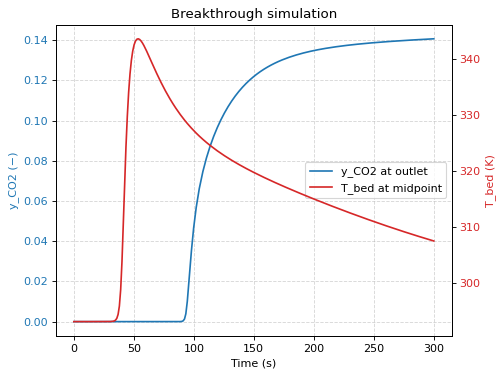

In [8]:
import matplotlib.pyplot as plt
from pysorb.bt import run_simulation

PROCESS       = dict(Flow_in=1200.0, T0=293.15, T_in=293.15, T_amb=293.15, P_amb=1.01325e5, P_out=1.1e5, mu=1.75e-05)
BED           = dict(L=0.12, dia_in=0.01, eps_b=0.5)
PELLET        = dict(dia_p=0.001, rho_s=1100.0, Cp_s=900.0)
WALL          = dict(rho_w=7850.0, Cp_w=420.0, w_w=0.001)
TRANSPORT     = dict(Dm=1.46e-05, DL_model="Gunn")
HEAT_TRANSFER = dict(h_in=60.0, h_out=9.0, kz=0.1, kw=16.0)
DOMAIN        = dict(t_end=300.0, N=50, dt=0.1, dt_min=0.0001, dt_max=3.0, tol_err=0.001)
SOLVER        = dict(newton_tol=0.002, newton_max_iter=10, newton_delta=1e-6, newton_alpha=1.0,
                     newton_min_alpha=1e-6, newton_line_search_max=16, startup_dt_min=0.001,
                     newton_retry_max_iter=25, max_rejected_steps=5000)

# (name, y_in, initial_y, Cp_gas, MW, ldf, d_h_ads, [(model, qs, b, d_h), ...])
COMPONENTS = [
    ("CO2", 0.15, 1e-12, 37.23, 0.044, 0.13, -42000.0, [("Langmuir", 2.08, 3.52e-06, -45793.0),
                                                          ("Langmuir", 3.03, 1.32e-06, -37988.0)]),
    ("N2",  0.85, 1.0,   29.17, 0.028, 6.59, -30555.0, [("Langmuir", 2.08, 2.9e-07,  -30555.0),
                                                          ("Langmuir", 3.03, 2.9e-07,  -30555.0)]),
]

def build(name, y_in, initial_y, Cp_gas, MW, ldf, d_h_ads, sites):
    return dict(name=name, y_in=y_in, initial_y=initial_y, Cp_gas=Cp_gas, MW=MW, ldf=ldf,
                d_h_ads=d_h_ads,
                isotherms=[{"model": s[0], "params": list(s[1:-1]), "d_h": s[-1]} for s in sites])

out     = run_simulation(dict(components=[build(*c) for c in COMPONENTS], process=PROCESS,
                              bed=BED, pellet=PELLET, wall=WALL, transport=TRANSPORT,
                              heat_transfer=HEAT_TRANSFER, domain=DOMAIN, solver=SOLVER,
                              q_eq_method="ext", isotherm_t_ref=0.0))
time    = out["time"]
results = out["results"]
n_grid  = len(out["z_axis"])
n_comp  = len(COMPONENTS)

y_CO2 = results[:, :n_grid][:, -1]
T_mid  = results[:, 2*n_comp*n_grid:(2*n_comp+1)*n_grid][:, n_grid // 2]

fig, ax1 = plt.subplots(dpi=80)
ax1.plot(time, y_CO2, color="tab:blue",  label="y_CO2 at outlet")
ax1.set_xlabel("Time (s)"); ax1.set_ylabel("y_CO2 (−)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(time, T_mid, color="tab:red", label="T_bed at midpoint")
ax2.set_ylabel("T_bed (K)", color="tab:red"); ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.legend(ax1.get_lines() + ax2.get_lines(),
           [l.get_label() for l in ax1.get_lines() + ax2.get_lines()], loc="center right")
ax1.set_title("Breakthrough simulation"); ax1.grid(True, ls="--", alpha=0.5)
fig.tight_layout(); plt.show()


pysorb Crank Example

Fitted parameters:
  D/R² = 0.00132323 s⁻¹
  MAE  = 0.0153927


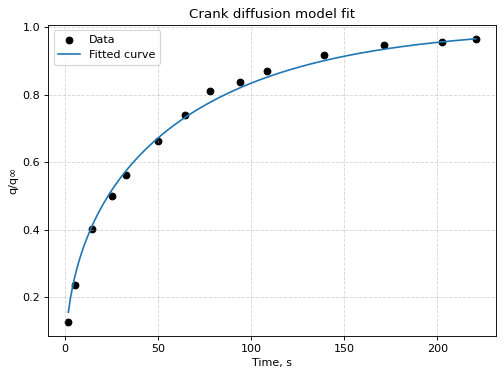

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pysorb.crank import crank_uptake, fit_D_R2

# Data: time and q/q∞
data = np.array([
    [1.7236,   0.1270],
    [5.2455,   0.2365],
    [14.7000,  0.4007],
    [24.9312,  0.4984],
    [32.9486,  0.5609],
    [50.1263,  0.6625],
    [64.5307,  0.7407],
    [77.9938,  0.8110],
    [93.7727,  0.8363],
    [108.2862, 0.8714],
    [139.2483, 0.9181],
    [171.4016, 0.9473],
    [202.4790, 0.9568],
    [220.5174, 0.9645],
])

t = data[:, 0]
q_ratio = data[:, 1]

# Fit the diffusion coefficient
D_R2, MAE = fit_D_R2(t, q_ratio)
# D_R2 is D/R² in s⁻¹; MAE is the mean absolute error

# Generate fitted curve
t_fit = np.linspace(t.min(), t.max(), 200)
q_fit = crank_uptake(t_fit, D_R2)

print(f"Fitted parameters:")
print(f"  D/R² = {D_R2:.6g} s⁻¹")
print(f"  MAE  = {MAE:.6g}")

# Plot data and fitted curve
plt.figure(dpi=80)
plt.scatter(t, q_ratio, color="black", label="Data")
plt.plot(t_fit, q_fit, color="tab:blue", label="Fitted curve")
plt.xlabel("Time, s")
plt.ylabel("q/q∞")
plt.title("Crank diffusion model fit")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

pysorb zlc Example

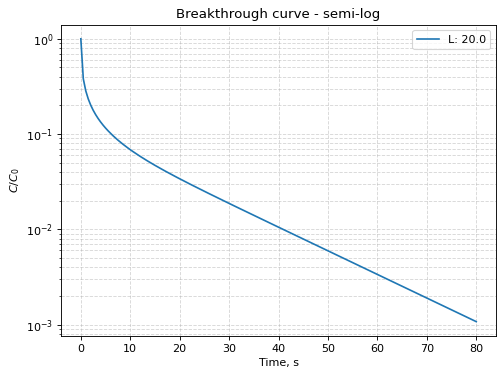

In [10]:
from pysorb.zlc import linmodel
import matplotlib.pyplot as plt

t, c, c_preload, q, q_preload, sigsum = linmodel(
    Lsat=20,
    DR2=6.4e-3,
    gamma=0.001,
    tsat=50,
    t_end=80,
    NN="auto",
)

# Plot c vs t, semi-log
plt.figure(dpi=80)
plt.semilogy(t, c, label="L: 20.0")
plt.xlabel("Time, s")
plt.ylabel("$C/C_0$")
plt.title("Breakthrough curve - semi-log")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()